In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

ml_df = pd.read_csv('../data/processed/trip_level_ml_ready.csv')
ml_df.shape

(14787, 30)

In [3]:
ml_df.dtypes

route_type                         object
start_scan_to_end_scan            float64
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
source_state                       object
destination_state                  object
source_city_code                   object
destination_city_code              object
trip_duration_minutes             float64
trip_duration_hours               float64
osrm_error                        float64
delay_percentage                  float64
delay_flag                          int64
is_interstate                        bool
corridor_id                        object
distance_category                  object
creation_year                       int64
creation_month                      int64
creation_day                      

In [4]:
baseline_mae = mean_absolute_error(ml_df['actual_time'], ml_df['osrm_time'])
baseline_rmse = np.sqrt(mean_squared_error(ml_df['actual_time'], ml_df['osrm_time']))

print(f"Baseline (OSRM) MAE: {baseline_mae:.2f} minutes")
print(f"Baseline (OSRM) RMSE: {baseline_rmse:.2f} minutes")

Baseline (OSRM) MAE: 1987.05 minutes
Baseline (OSRM) RMSE: 7710.54 minutes


In [5]:
ml_df.dtypes.iloc[10:20]

destination_state         object
source_city_code          object
destination_city_code     object
trip_duration_minutes    float64
trip_duration_hours      float64
osrm_error               float64
delay_percentage         float64
delay_flag                 int64
is_interstate               bool
corridor_id               object
dtype: object

In [6]:
ml_df.dtypes.iloc[20:30]

distance_category     object
creation_year          int64
creation_month         int64
creation_day           int64
creation_day_name     object
is_weekend              bool
creation_hour          int64
creation_quarter       int64
route_efficiency     float64
time_efficiency      float64
dtype: object

In [7]:
# Drop leakage columns
leakage_cols = ['osrm_error', 'delay_percentage', 'delay_flag', 'time_efficiency', 
                 'trip_duration_minutes', 'trip_duration_hours', 'start_scan_to_end_scan',
                 'segment_actual_time', 'actual_distance_to_destination', 'route_efficiency']

ml_df = ml_df.drop(columns=leakage_cols, errors='ignore')

# Separate target
X = ml_df.drop(columns=['actual_time'])
y = ml_df['actual_time']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.dtypes

Features shape: (14787, 19)
Target shape: (14787,)


route_type                object
osrm_time                float64
osrm_distance            float64
segment_osrm_time        float64
segment_osrm_distance    float64
source_state              object
destination_state         object
source_city_code          object
destination_city_code     object
is_interstate               bool
corridor_id               object
distance_category         object
creation_year              int64
creation_month             int64
creation_day               int64
creation_day_name         object
is_weekend                  bool
creation_hour              int64
creation_quarter           int64
dtype: object

In [8]:
# Check how many unique values each categorical column has
# This tells us which encoding strategy to use for each column
categorical_cols = X.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")

route_type: 2 unique values
source_state: 29 unique values
destination_state: 32 unique values
source_city_code: 665 unique values
destination_city_code: 761 unique values
corridor_id: 156 unique values
distance_category: 4 unique values
creation_day_name: 7 unique values


In [9]:
# Convert boolean columns to 0/1 integers (models need numeric input, not True/False)
X = X.copy()
X['is_interstate'] = X['is_interstate'].astype(int)
X['is_weekend'] = X['is_weekend'].astype(int)

# Low-cardinality columns -> One-Hot Encoding
# Creates a separate 0/1 column per category; safe here since these have few unique values
low_card_cols = ['route_type', 'distance_category', 'creation_day_name']
X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=True)

# High-cardinality columns -> Label Encoding
# Converts each unique text value to a single number; avoids creating hundreds of new columns
from sklearn.preprocessing import LabelEncoder

high_card_cols = ['source_state', 'destination_state', 'source_city_code', 
                   'destination_city_code', 'corridor_id']

le_dict = {}  # save each column's encoder in case we need it later (e.g. for the Streamlit app)
for col in high_card_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    le_dict[col] = le

print("Final feature shape after encoding:", X_encoded.shape)
X_encoded.head()

Final feature shape after encoding: (14787, 26)


,osrm_time,osrm_distance,segment_osrm_time,segment_osrm_distance,source_state,destination_state,source_city_code,destination_city_code,is_interstate,corridor_id,...,route_type_FTL,distance_category_100-300km,distance_category_300-600km,distance_category_600+km,creation_day_name_Monday,creation_day_name_Saturday,creation_day_name_Sunday,creation_day_name_Thursday,creation_day_name_Tuesday,creation_day_name_Wednesday
0,7787.0,10577.7647,1008.0,1320.4733,16,11,106,270,1,83,...,True,False,False,True,False,False,False,False,False,True
1,210.0,269.4308,65.0,84.1894,14,15,633,162,0,71,...,False,True,False,False,False,False,False,False,False,True
2,65768.0,89447.2488,1941.0,2545.2678,14,24,61,154,1,75,...,True,False,False,True,False,False,False,False,False,True
3,24.0,31.6475,16.0,19.8766,17,18,431,485,0,97,...,False,False,False,False,False,False,False,False,False,True
4,207.0,266.2914,115.0,146.7919,14,15,82,90,0,71,...,True,True,False,False,False,False,False,False,False,True


In [10]:
# Split data: 80% for training the model, 20% held out for testing
# random_state ensures we get the same split every time we run this (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (11829, 26)
Test set size: (2958, 26)


In [11]:
# Recalculate baseline (OSRM) error, but only on the test set
# This ensures a fair, apples-to-apples comparison with our model's test performance
osrm_test = ml_df.loc[X_test.index, 'osrm_time']
baseline_mae_test = mean_absolute_error(y_test, osrm_test)
baseline_rmse_test = np.sqrt(mean_squared_error(y_test, osrm_test))

print(f"Baseline (OSRM) MAE on test set: {baseline_mae_test:.2f} minutes")
print(f"Baseline (OSRM) RMSE on test set: {baseline_rmse_test:.2f} minutes")

Baseline (OSRM) MAE on test set: 2007.89 minutes
Baseline (OSRM) RMSE on test set: 7551.70 minutes


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import time

# Dictionary to store results of every model we try
# This becomes our comparison table for choosing the best one
results = []

# Baseline (OSRM) - not a model, but our reference point to beat
results.append({
    'Model': 'OSRM Baseline (not a model)',
    'MAE': baseline_mae_test,
    'RMSE': baseline_rmse_test,
    'R2': r2_score(y_test, osrm_test),
    'Train Time (s)': 0
})

# Model 1: Linear Regression (simplest baseline model)
# Good starting point - assumes a straight-line relationship between features and target
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append({
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test, lr_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_pred)),
    'R2': r2_score(y_test, lr_pred),
    'Train Time (s)': round(time.time() - start, 2)
})

# Model 2: Decision Tree (single tree, can capture non-linear patterns but prone to overfitting)
start = time.time()
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
results.append({
    'Model': 'Decision Tree',
    'MAE': mean_absolute_error(y_test, dt_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, dt_pred)),
    'R2': r2_score(y_test, dt_pred),
    'Train Time (s)': round(time.time() - start, 2)
})

# Model 3: Random Forest (many trees averaged together, reduces overfitting vs single tree)
start = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'R2': r2_score(y_test, rf_pred),
    'Train Time (s)': round(time.time() - start, 2)
})

# Model 4: XGBoost (gradient boosting, builds trees sequentially to fix previous errors)
start = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
results.append({
    'Model': 'XGBoost',
    'MAE': mean_absolute_error(y_test, xgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'R2': r2_score(y_test, xgb_pred),
    'Train Time (s)': round(time.time() - start, 2)
})

# Build comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,Train Time (s)
0,Random Forest,328.435589,1257.335090,0.993487,5.27
1,XGBoost,353.528047,1370.534178,0.992261,0.83
2,Decision Tree,428.698687,2480.444893,0.974652,0.15
3,Linear Regression,519.695583,1580.249741,0.989712,0.03
4,OSRM Baseline (not a model),2007.894523,7551.703574,0.765051,0.00


In [13]:
# Calculate improvement over baseline for the interview talking point
improvement_pct = (baseline_mae_test - results_df.loc[0, 'MAE']) / baseline_mae_test * 100
print(f"Best Model: {results_df.loc[0, 'Model']}")
print(f"Improvement over OSRM baseline: {improvement_pct:.1f}%")

Best Model: Random Forest
Improvement over OSRM baseline: 83.6%


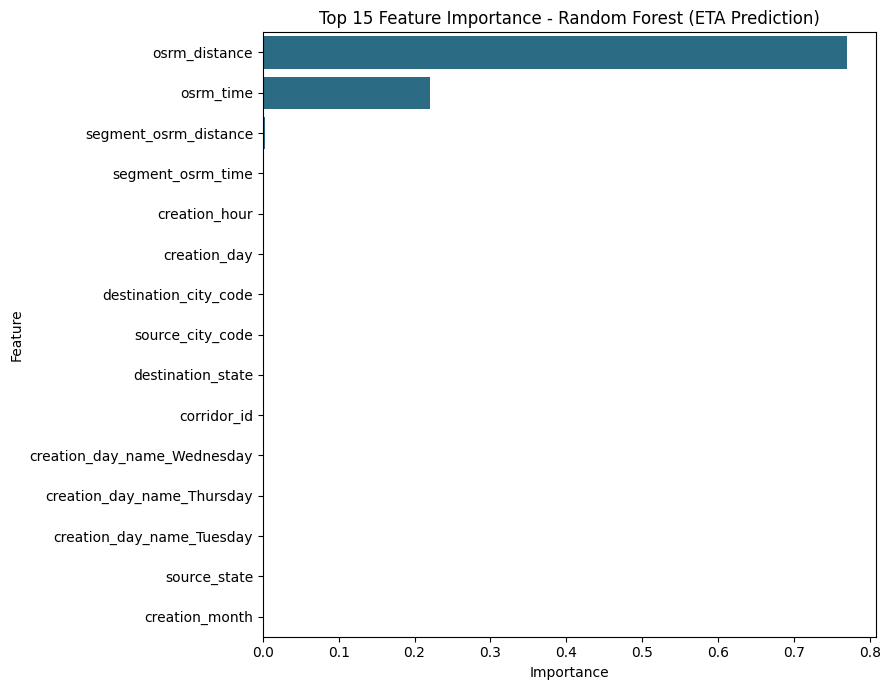

,Feature,Importance
1,osrm_distance,0.769529
0,osrm_time,0.220310
3,segment_osrm_distance,0.002515
2,segment_osrm_time,0.001876
14,creation_hour,0.001426
12,creation_day,0.000774
7,destination_city_code,0.000625
6,source_city_code,0.000603
5,destination_state,0.000406
9,corridor_id,0.000368


In [14]:
# Get feature importance from Random Forest - shows which features drive predictions most
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='#1C7293')
plt.title('Top 15 Feature Importance - Random Forest (ETA Prediction)')
plt.tight_layout()
plt.show()

importance_df

In [15]:
# Experiment: Train without OSRM features to see how much predictive power 
# comes from context alone (corridor, time, route type) vs OSRM's own estimate
X_train_no_osrm = X_train.drop(columns=['osrm_time', 'osrm_distance', 'segment_osrm_time', 'segment_osrm_distance'])
X_test_no_osrm = X_test.drop(columns=['osrm_time', 'osrm_distance', 'segment_osrm_time', 'segment_osrm_distance'])

rf_no_osrm = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_no_osrm.fit(X_train_no_osrm, y_train)
pred_no_osrm = rf_no_osrm.predict(X_test_no_osrm)

print(f"MAE without OSRM features: {mean_absolute_error(y_test, pred_no_osrm):.2f} minutes")
print(f"(For comparison) MAE with OSRM features: {results_df.loc[0, 'MAE']:.2f} minutes")
print(f"(For comparison) OSRM baseline alone: {baseline_mae_test:.2f} minutes")

MAE without OSRM features: 590.92 minutes
(For comparison) MAE with OSRM features: 328.44 minutes
(For comparison) OSRM baseline alone: 2007.89 minutes


In [16]:
import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/eta_prediction_model.pkl')
joblib.dump(le_dict, '../models/label_encoders_eta.pkl')
print("ETA model saved!")

ETA model saved!
